# Changing Bases Using Eulerian Transforms

Here is a demonstration of the Eulerian change of basis idea.

In [1]:
%load_ext autoreload
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../..')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_default_dtype(torch.float64)

## Eulerian Transformations Using Infinitesimal Givens Rotations

In [2]:
%autoreload 2 
from infidictionary.neural_isometries import EulerianIsometry
from infidictionary.utils import TimeEvolvingField
from infidictionary.utils import MLPNeuralField
import functools

# manual seed for reproducibility
torch.manual_seed(0)
isometry = EulerianIsometry(
    coords_dim=2,
    channels_dim=1,
    scalar_field_partial=functools.partial(
        TimeEvolvingField,
        base_field_partial=functools.partial(
            MLPNeuralField,
            hidden_dims=dict(a=64, b=64),
            activation=torch.nn.ReLU,
        ),
    ),
).to(device)



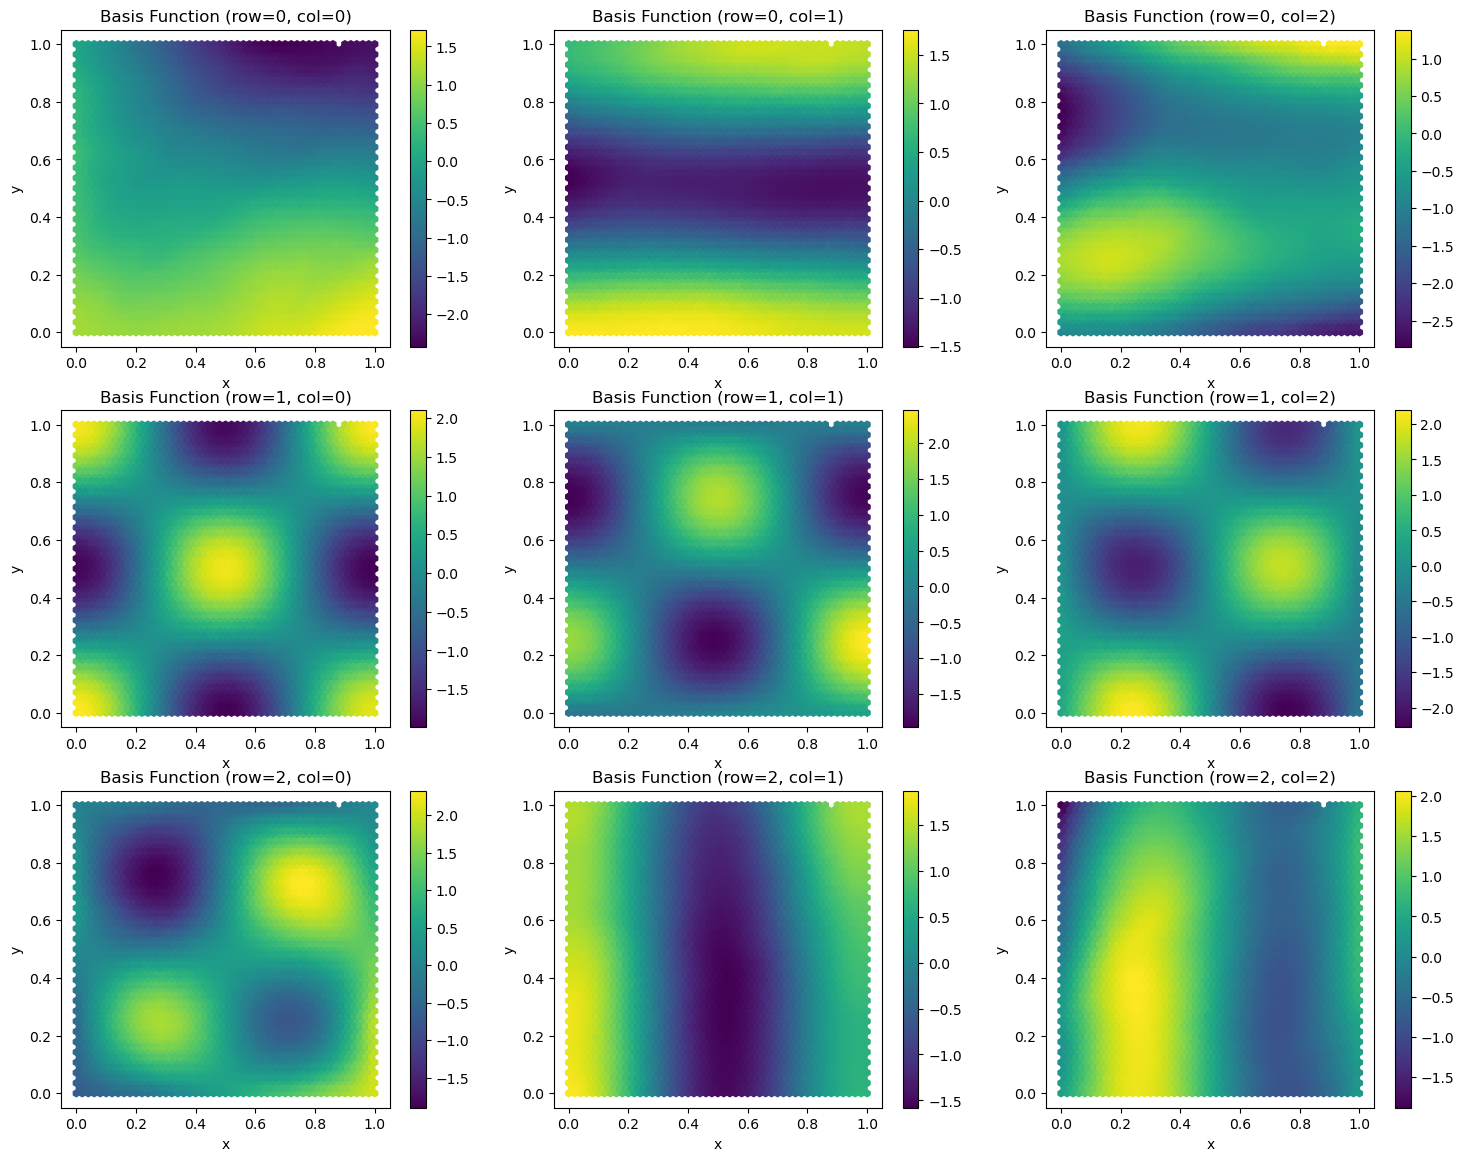

In [3]:
%autoreload 2
from infidictionary.dictionaries import FourierDictionary
from infidictionary.domain_samplers import SquareSampler

fourier_basis = FourierDictionary()
indices = [
    [0, 1, 2],
    [3, 4, 5], 
    [6, 7, 8],
]
indices_tensorized = torch.tensor(indices).to(device).flatten()

# seed everything for reproducibility
torch.manual_seed(0)
N_per_dim = 200
end_time = 5.5
all_deformed_vals = []
all_vals = []
xy = SquareSampler().sample(N_per_dim).to(device)
all_vals = fourier_basis.get_atom(xy, indices_tensorized).unsqueeze(-1)
isometry.reshuffle_time_discretization(20)
src_coords, src_logabsdet, all_vals_transformed = isometry.pushforward(
    xy,
    torch.zeros(xy.shape[0], device=xy.device),
    all_vals,
    start_time=0.0,
    end_time=5.0,
)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18,14))
for row in range(3):
    for col in range(3):
        ax = axes[row, col]
        idx = indices[row][col]
        # approximate integral by monte carlo
        ax.hexbin(
            src_coords[:,0].detach().cpu(), 
            src_coords[:,1].detach().cpu(), 
            C=all_vals_transformed[row * 3 + col].detach().cpu().squeeze(-1), 
            gridsize=50, 
            cmap='viridis',
        ) 
        plt.colorbar(mappable=ax.collections[0], ax=ax)
        ax.set_title(f'Basis Function (row={row}, col={col})')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
plt.show()


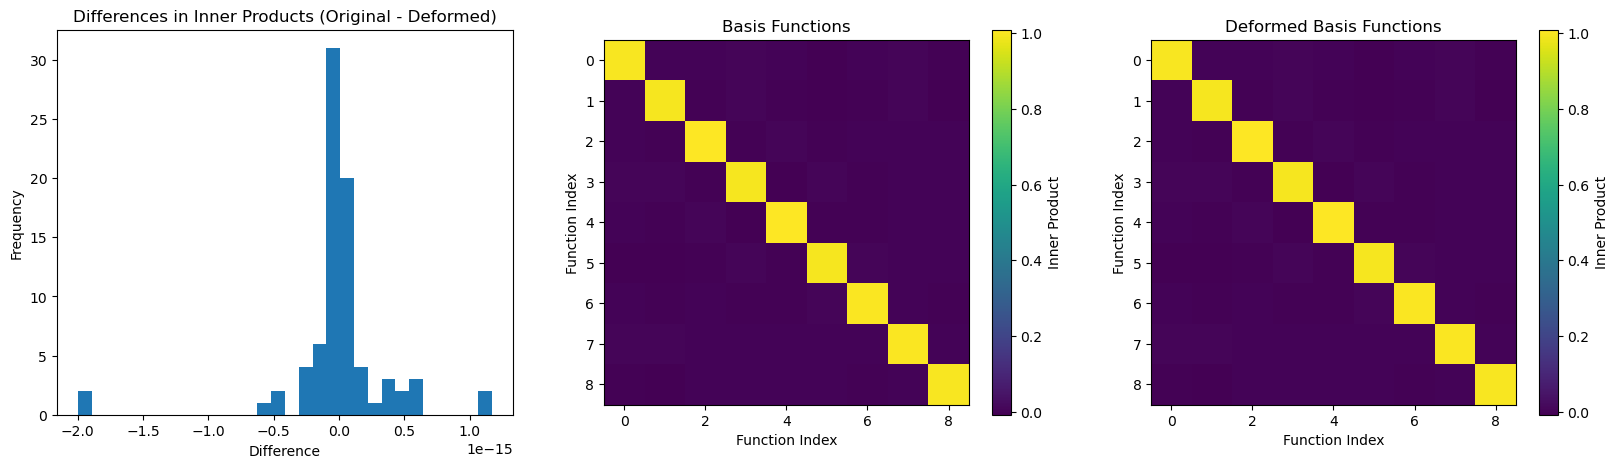

In [4]:
%autoreload 2
from infidictionary.utils import pairwise_inner_product

# compute pairwise inner products
N = N_per_dim ** 2
inner_products = pairwise_inner_product(all_vals, all_vals)
inner_products_deformed = pairwise_inner_product(all_vals_transformed, all_vals_transformed, logabsdet=src_logabsdet)
fig, axes = plt.subplots(figsize=(20, 5), nrows=1, ncols=3)
# heatmap of inner products
m = axes[2].imshow(inner_products_deformed.detach().cpu())
fig.colorbar(m, ax=axes[2], label='Inner Product')
axes[2].set_title('Deformed Basis Functions')
axes[2].set_xlabel('Function Index')
axes[2].set_ylabel('Function Index')

m = axes[1].imshow(inner_products.detach().cpu())
fig.colorbar(m, ax=axes[1], label='Inner Product')
axes[1].set_title('Basis Functions')
axes[1].set_xlabel('Function Index')
axes[1].set_ylabel('Function Index')

diffs = inner_products - inner_products_deformed
axes[0].hist(diffs.flatten().detach().cpu(), bins=30)
axes[0].set_title('Differences in Inner Products (Original - Deformed)')
axes[0].set_xlabel('Difference')
axes[0].set_ylabel('Frequency')
plt.show()


# Check pullback pushforward consistency

torch.Size([3, 90000, 1])


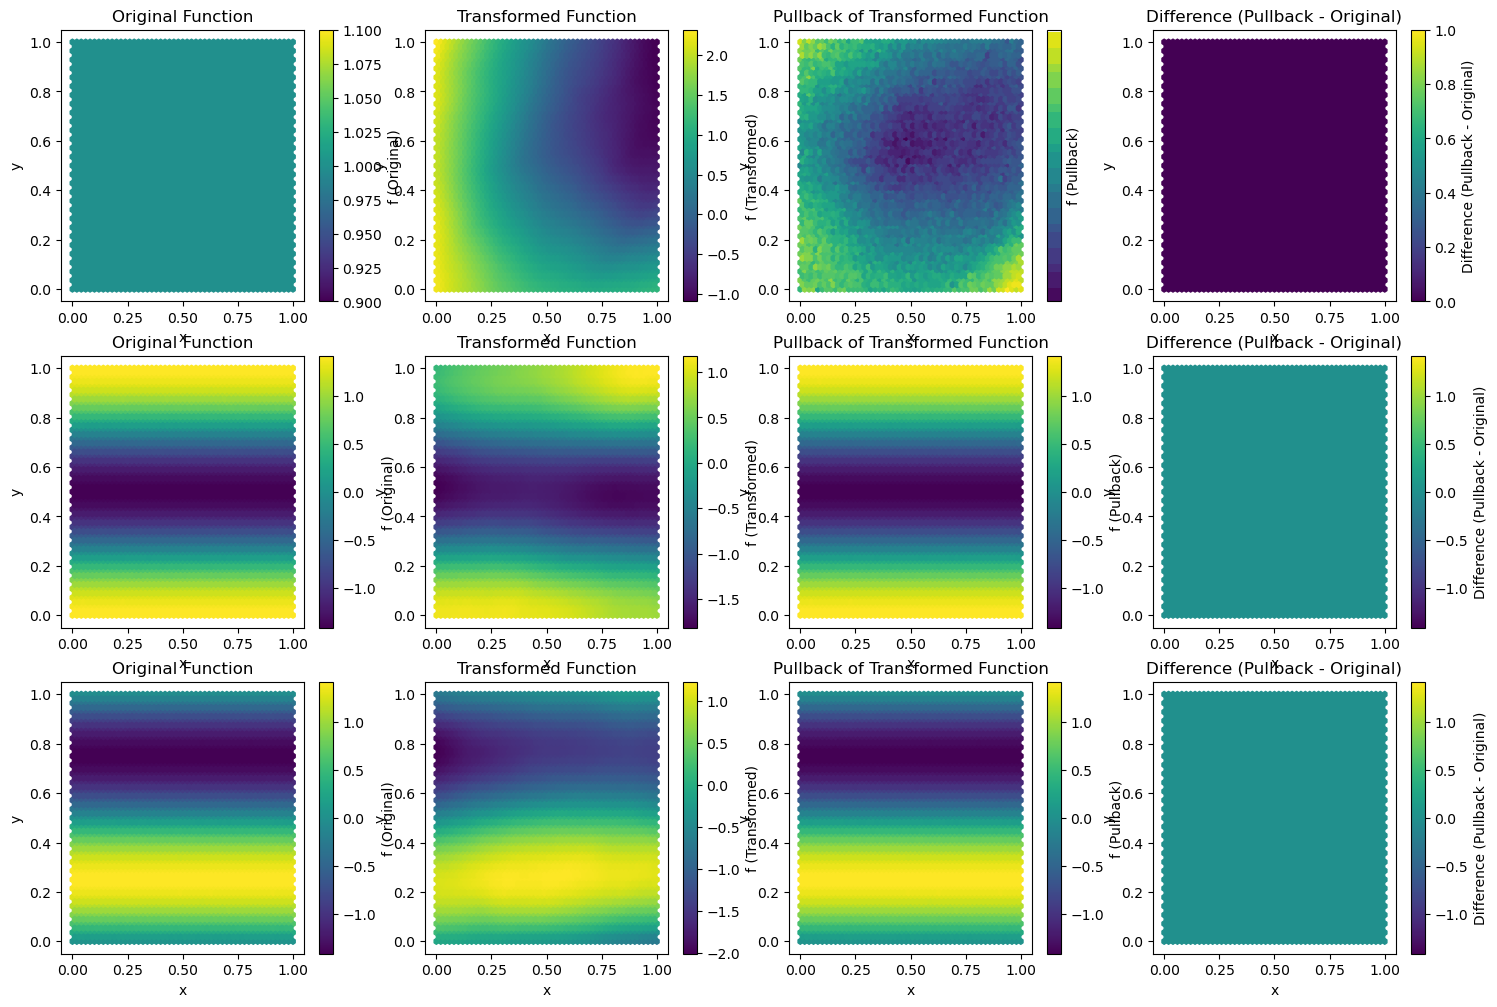

In [5]:
%autoreload 2 
from infidictionary.datasets import RandomBandpassGenerator
from infidictionary.domain_samplers import SquareSampler

start_time = 0.0
end_time = 5.0
N_per_dim = 300
inner_steps = 20

bandpass_gen = RandomBandpassGenerator(
    radial=False,
    omega_lo=5,
    omega_hi=10,
    r_lo=0.5,
    r_hi=1.0,
    l_sin=5,
    l_cos=5,
    seed=1024,
)
isometry.reshuffle_time_discretization(inner_steps)
sampler2 = SquareSampler(stratified=True, add_noise=True)
coords = sampler2.sample(N_per_dim).to(device)
# f = bandpass_gen.get_batch(
#     coords,
#     seeds=torch.tensor([0, 1, 2]),
# ).unsqueeze(-1).to(device)

f = FourierDictionary().get_atom(coords, torch.tensor([0, 1, 2]).to(device)).to(device).unsqueeze(-1) # (3, N, 1)
print(f.shape)

coords, logabsdet, f_transformed = isometry.pushforward(
    coords,
    torch.zeros(coords.shape[0], device=coords.device),
    f,
    start_time=start_time,
    end_time=end_time,
)
coords, logabsdet, f_transformed_pullback = isometry.pullback(
    coords,
    logabsdet,
    f_transformed,
    start_time=start_time,
    end_time=end_time,
)

diff = f_transformed_pullback - f

fig, axes = plt.subplots(nrows=len(f), ncols=4, figsize=(18, 4 * len(f)))

for i in range(len(f)):
    axes[i, 0].hexbin(
        coords[:,0].detach().cpu(), 
        coords[:,1].detach().cpu(), 
        C=f[i].detach().cpu().squeeze(-1), 
        gridsize=50, 
        cmap='viridis',
    )
    plt.colorbar(mappable=axes[i,0].collections[0], ax=axes[i,0], label='f (Original)') 
    axes[i,0].set_title('Original Function')
    axes[i,0].set_xlabel('x')
    axes[i,0].set_ylabel('y')

    axes[i,1].hexbin(
        coords[:,0].detach().cpu(), 
        coords[:,1].detach().cpu(),
        C=f_transformed[i].detach().cpu().squeeze(-1), 
        gridsize=50, 
        cmap='viridis',
    )
    plt.colorbar(mappable=axes[i,1].collections[0], ax=axes[i,1], label='f (Transformed)') 
    axes[i,1].set_title('Transformed Function')
    axes[i,1].set_xlabel('x')
    axes[i,1].set_ylabel('y')

    axes[i,2].hexbin(
        coords[:,0].detach().cpu(), 
        coords[:,1].detach().cpu(),
        C=f_transformed_pullback[i].detach().cpu().squeeze(-1), 
        gridsize=50, 
        cmap='viridis',
    )
    plt.colorbar(mappable=axes[i,2].collections[0], ax=axes[i,2], label='f (Pullback)') 
    axes[i,2].set_title('Pullback of Transformed Function')
    axes[i,2].set_xlabel('x')
    axes[i,2].set_ylabel('y')

    axes[i, 3].hexbin(
        coords[:,0].detach().cpu(), 
        coords[:,1].detach().cpu(), 
        C=diff[i].detach().cpu().squeeze(-1), 
        gridsize=50, 
        cmap='viridis',
    )
    # add the elements in both axes[i, 3] and axes[i,0] to the colorbar so that the colorbar range covers both the original and the difference
    vmin = min(axes[i,0].collections[0].get_array().min(), axes[i,3].collections[0].get_array().min())
    vmax = max(axes[i,0].collections[0].get_array().max(), axes[i,3].collections[0].get_array().max())

    # 2. Update the mappable's limits explicitly
    mappable = axes[i,3].collections[0]
    mappable.set_clim(vmin, vmax)

    # 3. Create the colorbar (it will now use the new limits from the mappable)
    plt.colorbar(mappable, ax=axes[i,3], label='Difference (Pullback - Original)')

    axes[i,3].set_title('Difference (Pullback - Original)')
    axes[i,3].set_xlabel('x')
    axes[i,3].set_ylabel('y')

plt.show()


## Inner product

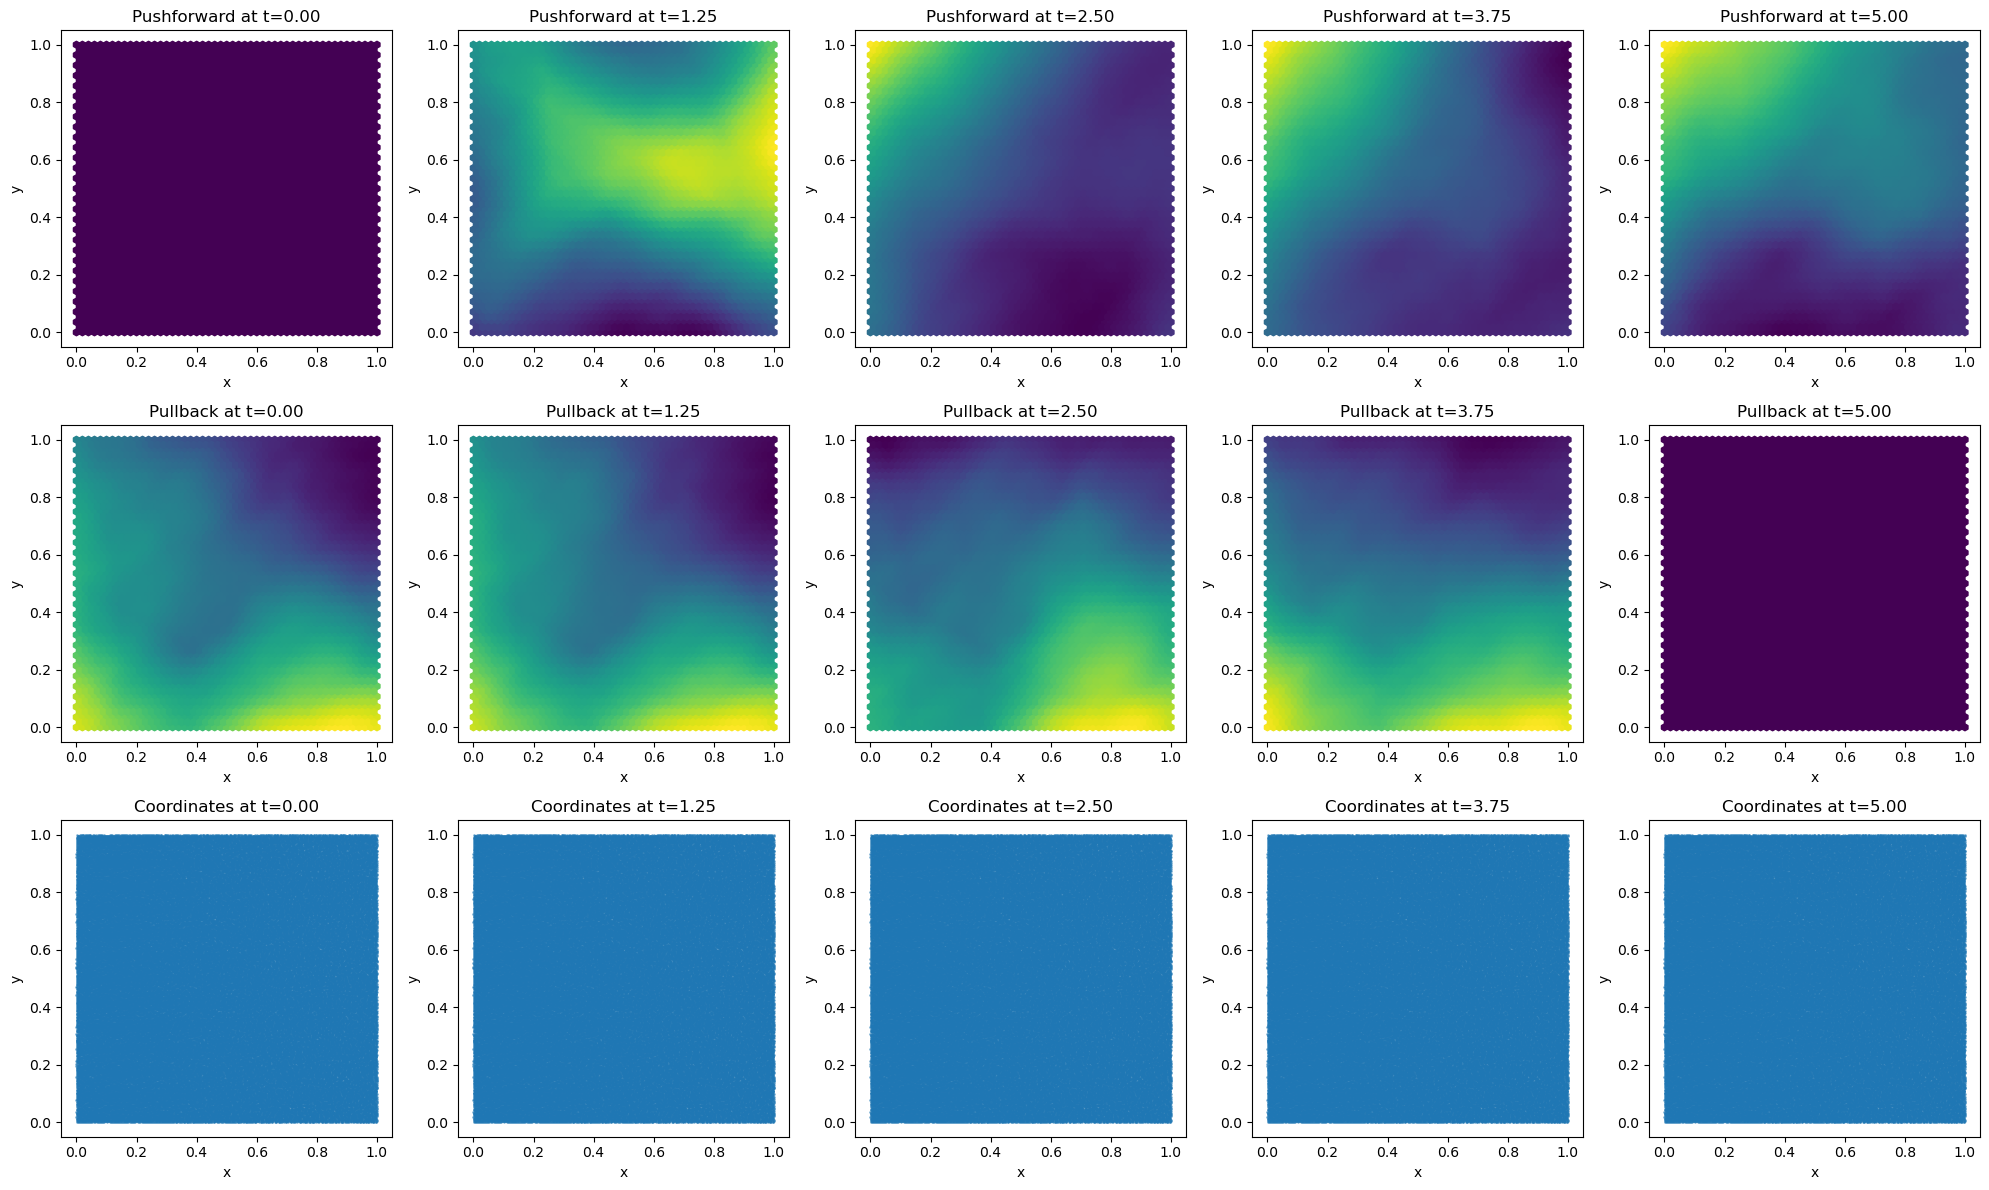

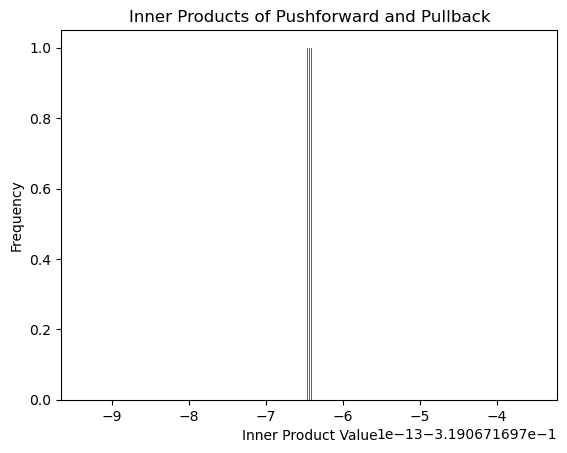

In [6]:
%autoreload 2 
from infidictionary.datasets import RandomBandpassGenerator
from infidictionary.neural_isometries import LagrangianIsometry
from infidictionary.dictionaries import FourierDictionary
from infidictionary.utils import parallel_inner_product
from infidictionary.diffeomorphisms import ShirlyChiu, PolarTransform
from infidictionary.domain_samplers import SquareSampler

start_time = 0.0
end_time = 5.0
n_frames = 5
N_per_dim = 300
inner_steps = 10
isometry.reshuffle_time_discretization(inner_steps)
sampler2 = SquareSampler(stratified=True, add_noise=True)
coords = sampler2.sample(N_per_dim).to(device)

f = FourierDictionary().get_atom(coords, torch.tensor([0]).to(device)).unsqueeze(-1).to(device).unsqueeze(0) # (1, N, 1)

phi = FourierDictionary().get_atom(coords, torch.tensor([0]).to(device)).unsqueeze(-1).to(device).unsqueeze(0) # (1, N, 1)

# --------------------------------------------------------


phi_pushforward = phi.clone().detach().cpu() # (1, N, 1)
tspan = torch.linspace(start_time, end_time, steps=n_frames).to(device)
logabsdet = torch.zeros(phi.shape[1], device=phi.device)
last_phi = phi
for t0, t1 in zip(tspan[:-1], tspan[1:]):
    coords, logabsdet, last_phi = isometry.pushforward(
        coords,
        logabsdet,
        last_phi,
        start_time=t0.item(),
        end_time=t1.item(),
    )
    phi_pushforward = torch.cat([phi_pushforward, last_phi.clone().detach().cpu()], dim=0) # (n_frames, N, 1)

# --------------------------------------------------------
f_pullback = f.clone().detach().cpu() # (1, N, 1)
tspan = torch.linspace(start_time, end_time, steps=n_frames).to(device).flip(0)
last_f = f
for t1, t0 in zip(tspan[:-1], tspan[1:]):
    coords, logabsdet, last_f = isometry.pullback(
        coords,
        logabsdet,
        last_f,
        start_time=t0.item(),
        end_time=t1.item(),
    )
    f_pullback = torch.cat([last_f.clone().detach().cpu(), f_pullback], dim=0)

# visualize the pushforward and pullback sequences
all_inner_products = parallel_inner_product(
    phi_pushforward,
    f_pullback,
    logabsdet=logabsdet.detach().cpu(), # ignore logabsdet for inner product since we are only interested in the difference between pushforward and pullback inner products, and they should have the same logabsdet values
)

coords = coords.detach().cpu()

fig, axes = plt.subplots(nrows=3, ncols=n_frames, figsize=(4 * n_frames, 3 * 4))
tspan = torch.linspace(start_time, end_time, steps=n_frames).to(device)
for i in range(n_frames):
    pushforward_vals = phi_pushforward[i,:,0]
    pullback_vals = f_pullback[i,:,0]

    axes[0, i].hexbin(coords[:, 0], coords[:, 1], C=pushforward_vals, gridsize=50, cmap='viridis')
    axes[0, i].set_title(f'Pushforward at t={tspan[i].item():.2f}')
    axes[0, i].set_xlabel('x')
    axes[0, i].set_ylabel('y')

    axes[1, i].hexbin(coords[:, 0], coords[:, 1], C=pullback_vals, gridsize=50, cmap='viridis')
    axes[1, i].set_title(f'Pullback at t={tspan[i].item():.2f}')
    axes[1, i].set_xlabel('x')
    axes[1, i].set_ylabel('y')

    # scatterplot for coordinates
    axes[2, i].scatter(coords[:, 0].detach().cpu(), coords[:, 1].detach().cpu(), s=1, alpha=0.5)
    axes[2, i].set_title(f'Coordinates at t={tspan[i].item():.2f}')
    axes[2, i].set_xlabel('x')
    axes[2, i].set_ylabel('y')


plt.tight_layout()
plt.show()

# heatmap of inner products)
plt.hist(all_inner_products.cpu().detach())
plt.title('Inner Products of Pushforward and Pullback')
plt.xlabel('Inner Product Value')
plt.ylabel('Frequency')    
plt.show()

